### Read in Median Age data csv, clean the 'Geography' column to be standardized, and output as geojson

In [3]:
import os
import re
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [11]:
notebook_dir = os.getcwd() 
secondary_data_dir = os.path.join(notebook_dir, "..", ".." , "data", "secondary_data")
median_age_csv = os.path.join(secondary_data_dir, "age_data", "median_age.csv")
map_path = os.path.join(secondary_data_dir, "age_data", "tl_2024_25_tract", "tl_2024_25_tract.shp")
output_geojson = os.path.join(secondary_data_dir, "age_data", "median_age_boundary.geojson")

In [16]:
STATE_FIPS = "25"   # Massachusetts
COUNTY_FIPS = "009" # Essex County

# COLUMN NAMES
COL_GEOG = "Geography"
COL_EST = "Total—Total population—SUMMARY INDICATORS—Median age (years)—Estimate"
COL_MOE = "MoE"

In [17]:
def load_and_clean_tracts_map(map_path, state_fips="25", county_fips="009"):
    """
    Read in TIGER tract shapefile and normalize NAME to match ACS text

    Example NAME in shapefile: '2501.01'
    We convert to 'Census Tract 2501'
    """
    gdf = gpd.read_file(map_path)

    # Filter by FIPS codes if present
    if "STATEFP" in gdf.columns and "COUNTYFP" in gdf.columns:
        gdf = gdf[(gdf["STATEFP"] == state_fips) & (gdf["COUNTYFP"] == county_fips)]

    # Normalize NAME to "Census Tract ####"
    gdf["NAME"] = gdf["NAME"].astype(str).str.split(".").str[0]
    gdf["NAME"] = "Census Tract " + gdf["NAME"]

    return gdf

In [18]:
def normalize_geography(text: str) -> str:
    """
    Turn 'Census Tract 2501; Essex County; Massachusetts'
    into 'Census Tract 2501, Essex County, Massachusetts'
    which matches how we have used it elsewhere
    """
    return re.sub(r"\s*;\s*", ", ", text.strip())

In [21]:
# 1) Read CSV and normalize the Geography text
df = pd.read_csv(median_age_csv, dtype=str, keep_default_na=False)

df[COL_GEOG] = df[COL_GEOG].apply(normalize_geography)

# Extract "Census Tract ####" for joining to tract NAME
df["tract"] = df[COL_GEOG].str.extract(r"(Census Tract \d+)")
print(df.head())


                                        Geography  \
0  Census Tract 2501, Essex County, Massachusetts   
1  Census Tract 2502, Essex County, Massachusetts   
2  Census Tract 2503, Essex County, Massachusetts   
3  Census Tract 2504, Essex County, Massachusetts   
4  Census Tract 2505, Essex County, Massachusetts   

  Total—Total population—SUMMARY INDICATORS—Median age (years)—Estimate  \
0                                               39.8                      
1                                               28.6                      
2                                               31.5                      
3                                               30.2                      
4                                                 28                      

     MoE              tract  
0  ± 9.9  Census Tract 2501  
1    ± 4  Census Tract 2502  
2  ± 8.3  Census Tract 2503  
3  ± 3.4  Census Tract 2504  
4  ± 2.3  Census Tract 2505  


In [22]:
# 2) Clean numeric fields for median age and MoE

# Median age like "39.8" to float
df["MedianAge"] = (
    df[COL_EST]
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

# MoE like "± 9.9" to float
df["MoE_clean"] = (
    df[COL_MOE]
    .str.replace("±", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

print(df[["tract", "MedianAge", "MoE_clean"]].head())

age_wide = df[["tract", "MedianAge", "MoE_clean"]].copy()

               tract  MedianAge  MoE_clean
0  Census Tract 2501       39.8        9.9
1  Census Tract 2502       28.6        4.0
2  Census Tract 2503       31.5        8.3
3  Census Tract 2504       30.2        3.4
4  Census Tract 2505       28.0        2.3


In [23]:
# 3) Load tract shapes and merge
tracts_gdf = load_and_clean_tracts_map(map_path, STATE_FIPS, COUNTY_FIPS)
merged_gdf = tracts_gdf.merge(age_wide, left_on="NAME", right_on="tract", how="left")

# Drop tracts with no match if you do not want them in the GeoJSON
merged_gdf = merged_gdf.dropna(subset=["MedianAge"])

# Ensure GeoDataFrame
merged_gdf = gpd.GeoDataFrame(merged_gdf, geometry="geometry", crs=tracts_gdf.crs)

In [24]:
# 4) Save GeoJSON
merged_gdf.to_file(output_geojson, driver="GeoJSON")
print(f"[DONE] Saved median age GeoJSON to: {output_geojson}")

[DONE] Saved median age GeoJSON to: c:\Users\Indel\Documents\gatewayinitiative-lawrencepd\scripts\secondary_data_scripts\..\..\data\secondary_data\age_data\median_age_boundary.geojson


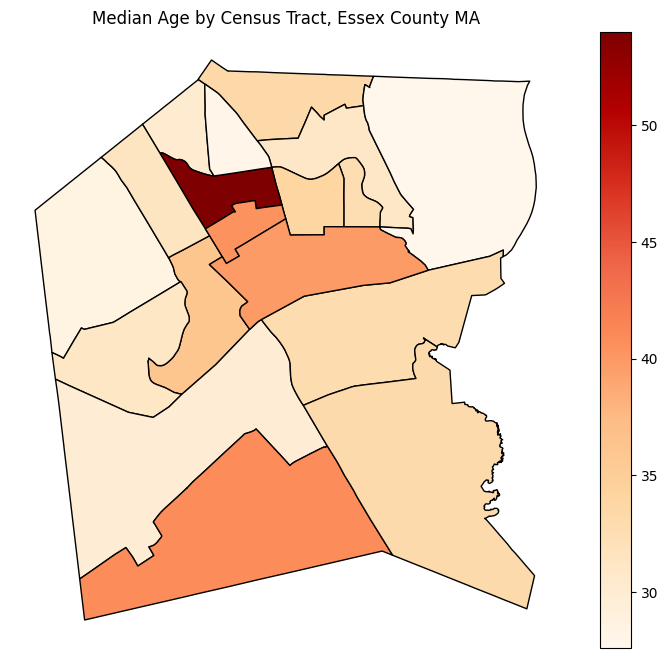

In [25]:
# 5) Plot choropleth
fig, ax = plt.subplots(figsize=(10, 8))
merged_gdf.plot(
    column="MedianAge",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)
ax.set_title("Median Age by Census Tract, Essex County MA")
plt.axis("off")
plt.show()